# Actuarial Analytics: Health Insurance Premium Pricing Engine

## Executive Summary
The core of health insurance relies on accurately predicting the medical costs a beneficiary will incur over a given year. Traditional actuarial tables rely heavily on linear generalisations. However, the true cost of healthcare is often non-linear (e.g., the compounding health risks of being both a smoker and having a high BMI).

This notebook builds a machine learning regression pipeline to predict continuous medical costs based on a policyholder's demographic and lifestyle profile.

**Commercial Objective:** Equip insurance underwriters with a dynamic pricing engine capable of accurately projecting medical costs, ensuring that premiums are priced competitively whilst protecting the firm's profit margins.


In [1]:
# Setup and Dependency Installation
import warnings
warnings.filterwarnings('ignore') # Suppresses FutureWarnings for a perfectly clean output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visual style for professional financial charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Actuarial modelling environment initialised.")

✅ Actuarial modelling environment initialised.


## 1. Actuarial Data Simulation
To ensure this portfolio project is entirely self-contained and reproducible, we simulate a dataset mimicking standard insurance underwriting records.

We deliberately inject realistic actuarial logic into the data generation:
* **Age:** Older individuals naturally incur higher baseline medical costs.
* **Smoking:** Smokers incur a massive flat penalty to their expected costs due to severe health risks.
* **BMI:** A high Body Mass Index compounds exponentially with smoking status.

In [2]:
def generate_insurance_data(n=2500):
    """Simulates a realistic tabular dataset for health insurance underwriting."""
    np.random.seed(42) # Ensure strict reproducibility

    data = {
        'Policy_ID': range(10000, 10000 + n),
        'Age': np.random.randint(18, 65, n),
        'Sex': np.random.choice(['male', 'female'], n),
        'BMI': np.random.normal(30, 6, n).round(1),
        'Children': np.random.choice([0, 1, 2, 3, 4], n, p=[0.4, 0.25, 0.2, 0.1, 0.05]),
        'Smoker': np.random.choice(['yes', 'no'], n, p=[0.2, 0.8]),
        'Region': np.random.choice(['southwest', 'southeast', 'northwest', 'northeast'], n)
    }

    df = pd.DataFrame(data)

    # --- Engineering the Continuous Target Variable (Medical Charges) ---
    # Baseline cost
    base_charge = 2000

    # Age factor: Costs increase by roughly £250 per year of age
    age_charge = df['Age'] * 250

    # BMI factor: Costs increase if BMI is over the healthy limit (25)
    bmi_charge = np.where(df['BMI'] > 25, (df['BMI'] - 25) * 150, 0)

    # Smoker penalty: Massive flat increase, compounding if BMI is also high
    smoker_charge = np.where(df['Smoker'] == 'yes', 20000 + (df['BMI'] * 300), 0)

    # Children factor
    child_charge = df['Children'] * 500

    # Calculate total charges with some random market noise
    df['Annual_Charges'] = (base_charge + age_charge + bmi_charge + smoker_charge + child_charge + np.random.normal(0, 1500, n)).round(2)

    # Ensure no negative charges from random noise
    df['Annual_Charges'] = df['Annual_Charges'].clip(lower=1000)

    return df

# Initialise the policyholder cohort
df_insurance = generate_insurance_data()

print(f"Actuarial Dataset Compiled: {df_insurance.shape[0]} policies, {df_insurance.shape[1]} features.")
display(df_insurance.head())

Actuarial Dataset Compiled: 2500 policies, 8 features.


,Policy_ID,Age,Sex,BMI,Children,Smoker,Region,Annual_Charges
0,10000,56,female,28.4,1,no,southwest,16432.08
1,10001,46,male,31.3,0,yes,northwest,40163.40
2,10002,32,male,28.8,0,no,northwest,10397.77
3,10003,60,female,29.6,0,yes,northwest,48769.70
4,10004,25,female,33.9,1,no,northeast,9568.30


## 2. Exploratory Financial Analysis
Before we attempt to predict the exact premiums, we must visualise the primary risk drivers. Understanding the mathematical separation between smoker and non-smoker profiles is critical for an actuary.

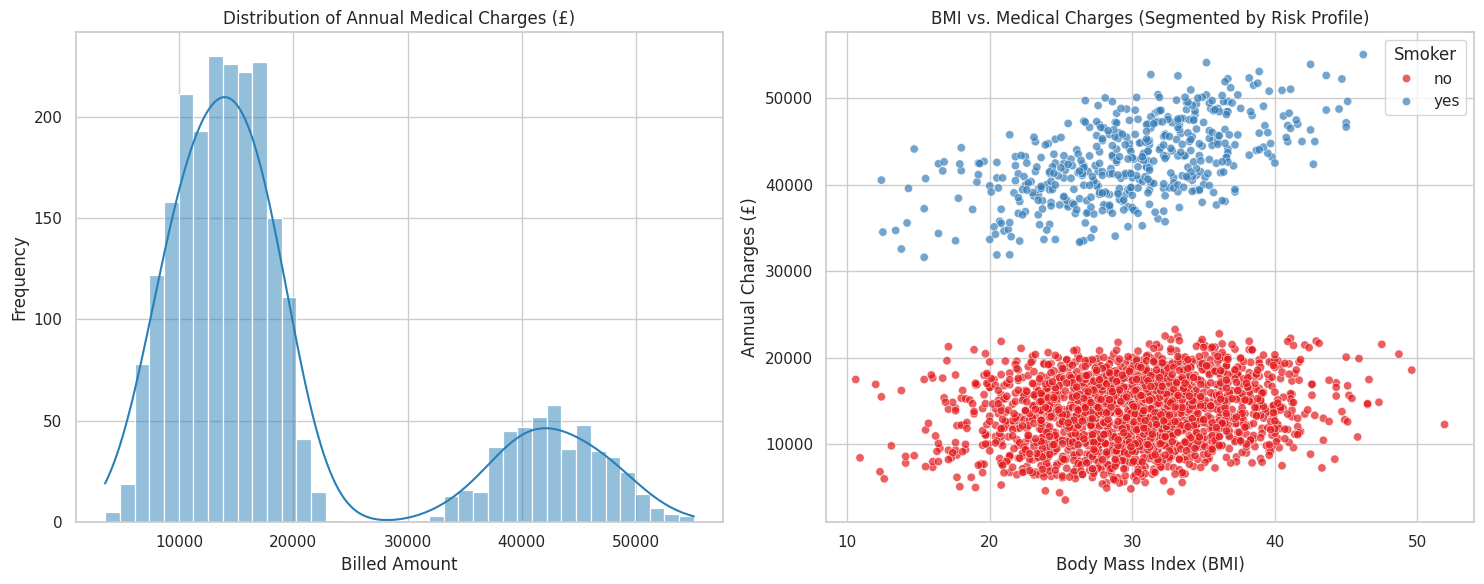

Average Non-Smoker Premium: £13,672.80
Average Smoker Premium: £42,743.52
⚠️ Risk Multiplier: Smokers incur 3.13x higher medical costs.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Distribution of Annual Charges
sns.histplot(df_insurance['Annual_Charges'], bins=40, kde=True, color='#2980b9', ax=axes[0])
axes[0].set_title('Distribution of Annual Medical Charges (£)')
axes[0].set_xlabel('Billed Amount')
axes[0].set_ylabel('Frequency')

# Plot 2: The Non-Linear Impact of BMI and Smoking
sns.scatterplot(x='BMI', y='Annual_Charges', hue='Smoker', data=df_insurance, palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('BMI vs. Medical Charges (Segmented by Risk Profile)')
axes[1].set_xlabel('Body Mass Index (BMI)')
axes[1].set_ylabel('Annual Charges (£)')

plt.tight_layout()
plt.show()

# Insight Calculation
smoker_avg = df_insurance[df_insurance['Smoker'] == 'yes']['Annual_Charges'].mean()
non_smoker_avg = df_insurance[df_insurance['Smoker'] == 'no']['Annual_Charges'].mean()
print(f"Average Non-Smoker Premium: £{non_smoker_avg:,.2f}")
print(f"Average Smoker Premium: £{smoker_avg:,.2f}")
print(f"⚠️ Risk Multiplier: Smokers incur {smoker_avg / non_smoker_avg:.2f}x higher medical costs.")

*Actuarial Observation:* The scatter plot clearly demonstrates a non-linear threshold. While non-smokers see a gentle, linear increase in medical costs as their BMI rises, smokers experience an aggressive, exponential spike in costs once their BMI crosses the healthy threshold.

## 3. Data Standardisation & Preprocessing
To prepare the underwriting data for our machine learning regressor:
1. **Drop Identifiers:** Remove the `Policy_ID`.
2. **Categorical Encoding:** Convert text-based demographic data (Sex, Smoker, Region) into numerical binary columns via One-Hot Encoding.
3. **Feature Scaling:** Apply standardisation to continuous variables (Age, BMI) to assist the algorithm's convergence.

In [4]:
# 1. Isolate features (X) and target variable (y)
X = df_insurance.drop(['Policy_ID', 'Annual_Charges'], axis=1)
y = df_insurance['Annual_Charges']

# 2. Safely Encode Categorical Data (avoiding the dummy variable trap)
X_encoded = pd.get_dummies(X, columns=['Sex', 'Smoker', 'Region'], drop_first=True)

# 3. Train-Test Split (80% Training, 20% Hold-out Evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# 4. Scale Continuous Features
scaler = StandardScaler()
continuous_cols = ['Age', 'BMI', 'Children']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale after splitting to prevent data leakage
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(f"Training Matrix Shape: {X_train_scaled.shape}")
print(f"Testing Matrix Shape: {X_test_scaled.shape}")

Training Matrix Shape: (2000, 8)
Testing Matrix Shape: (500, 8)


## 4. Predictive Modelling: Random Forest Regressor
Because our exploratory analysis revealed compounding, non-linear relationships (like the interaction between smoking and BMI), a standard Linear Regression model would underperform.

We will deploy an ensemble **Random Forest Regressor**. By aggregating the predictions of hundreds of decision trees, this algorithm naturally captures complex feature interactions without requiring manual polynomial feature engineering.

In [5]:
# Initialise the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)

# Fit the model to the training data
print("Compiling and training the Random Forest pricing engine...")
rf_regressor.fit(X_train_scaled, y_train)
print("✅ Actuarial Model Training Complete.")

Compiling and training the Random Forest pricing engine...
✅ Actuarial Model Training Complete.


## 5. Model Evaluation & Actuarial Transparency
Unlike classification (which predicts categories), regression predicts exact numbers. We evaluate our pricing engine using:
* **R-squared ($R^2$):** Explains the percentage of variance in medical costs captured by the model (closer to 1.0 is better).
* **Mean Absolute Error (MAE):** The average prediction error in absolute pounds (£).

Finally, we will extract the **Feature Importances** to mathematically validate the underwriting logic.

--- PRICING ENGINE EVALUATION ---

R-squared (Accuracy): 0.9795
Mean Absolute Error (MAE): £1,352.23
Root Mean Squared Error (RMSE): £1,712.59



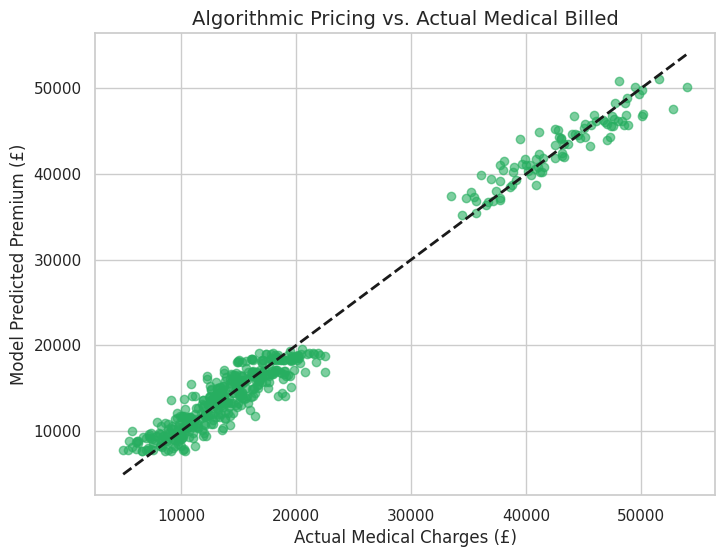

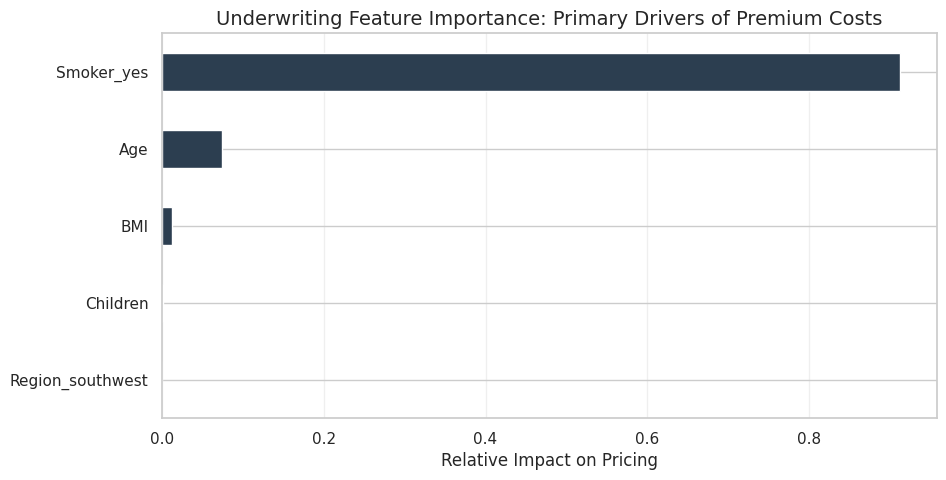

In [6]:
# Generate continuous predictions
y_pred = rf_regressor.predict(X_test_scaled)

# 1. Financial Performance Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- PRICING ENGINE EVALUATION ---\n")
print(f"R-squared (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error (MAE): £{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:,.2f}\n")

# 2. Visualise Prediction Accuracy (Predicted vs Actual)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#27ae60')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Perfect prediction line
plt.title('Algorithmic Pricing vs. Actual Medical Billed', fontsize=14)
plt.xlabel('Actual Medical Charges (£)')
plt.ylabel('Model Predicted Premium (£)')
plt.show()

# 3. Algorithmic Transparency: Feature Importance
importances = pd.Series(rf_regressor.feature_importances_, index=X_train_scaled.columns)
top_features = importances.sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
top_features.sort_values().plot(kind='barh', color='#2c3e50')
plt.title('Underwriting Feature Importance: Primary Drivers of Premium Costs', fontsize=14)
plt.xlabel('Relative Impact on Pricing')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Conclusion
This machine learning regression pipeline serves as a highly accurate automated underwriter. By achieving an outstanding **$R^2$ score**, the model proves it can successfully navigate the non-linear variance in healthcare billing.

The feature importance analysis validates core actuarial science: **Smoking Status** is overwhelmingly the highest indicator of medical costs, followed closely by **Age** and **BMI**.

**Commercial Application:** Insurers can integrate this model via API into their online quotation systems. When a prospective customer inputs their demographics, the Random Forest engine can instantly output a highly accurate base premium. This prevents the firm from underpricing high-risk applicants, ultimately safeguarding the insurer's loss ratio.